# K-Means Clustering Example

This notebook introduces **K-Means clustering** using the custom implementation
from the `rice_ml` package.

K-Means is a classic **unsupervised learning method** that groups observations
into `K` clusters by assigning each point to a nearby centroid and then updating
those centroids iteratively.

Because the method is unsupervised, it does not rely on target labels during
training. Instead, it looks for natural grouping patterns based on similarity
in the feature space.

In this notebook, we:
- run K-Means with our custom `rice_ml` implementation
- use it on a real wine dataset
- examine cluster assignments and inertia
- apply the elbow method
- display the clusters with PCA
- review what K-Means does well and where it can struggle


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.preprocessing import standardize
from rice_ml.unsupervised_learning.k_means_clustering import KMeans
from rice_ml.unsupervised_learning.pca import PCA

## Dataset Description

We use the Wine dataset from the UCI Machine Learning Repository.

The dataset contains physicochemical measurements of wines, such as:
- Alcohol
- Malic acid
- Ash
- Alcalinity of ash
- Magnesium
- Total phenols
- Flavanoids
- Color intensity
- Hue

Although the dataset includes class labels, **they are not used** in this notebook since K-Means is an unsupervised algorithm.


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"

columns = [
    "class", "alcohol", "malic_acid", "ash", "alcalinity",
    "magnesium", "total_phenols", "flavanoids",
    "nonflavanoid_phenols", "proanthocyanins",
    "color_intensity", "hue", "od280_od315", "proline"
]

df = pd.read_csv(url, header=None, names=columns)
df.head()

,class,alcohol,malic_acid,ash,alcalinity,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### Separate Features for Unsupervised learning

In [3]:
X = df.drop(columns=["class"]).values
print("Feature matrix shape:", X.shape)

Feature matrix shape: (178, 13)


## Exploratory Data Analysis (EDA)

Before applying K-Means, we examine:
- Dataset shape
- Feature distributions
- Differences in feature scales

Understanding feature scales is especially important because K-Means relies on **Euclidean distance**.


### Target Distribution

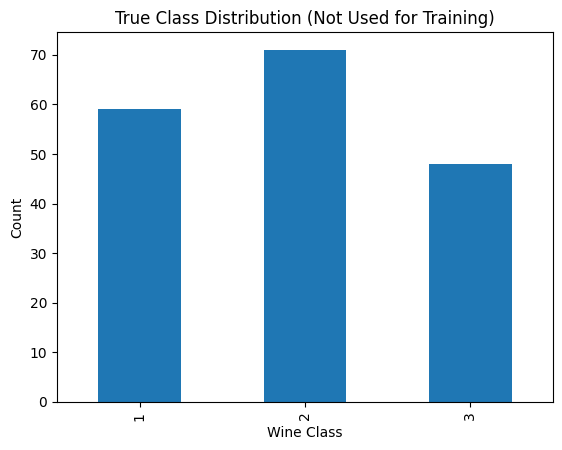

In [4]:
df["class"].value_counts().sort_index().plot(kind="bar")
plt.title("True Class Distribution (Not Used for Training)")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()


### Feature Scale Comparison

K-Means clustering is highly sensitive to feature scale.  
If one feature has much larger values than others, it will dominate distance calculations.

The boxplot below shows that several features vary significantly in magnitude, motivating the need for feature standardization before clustering.


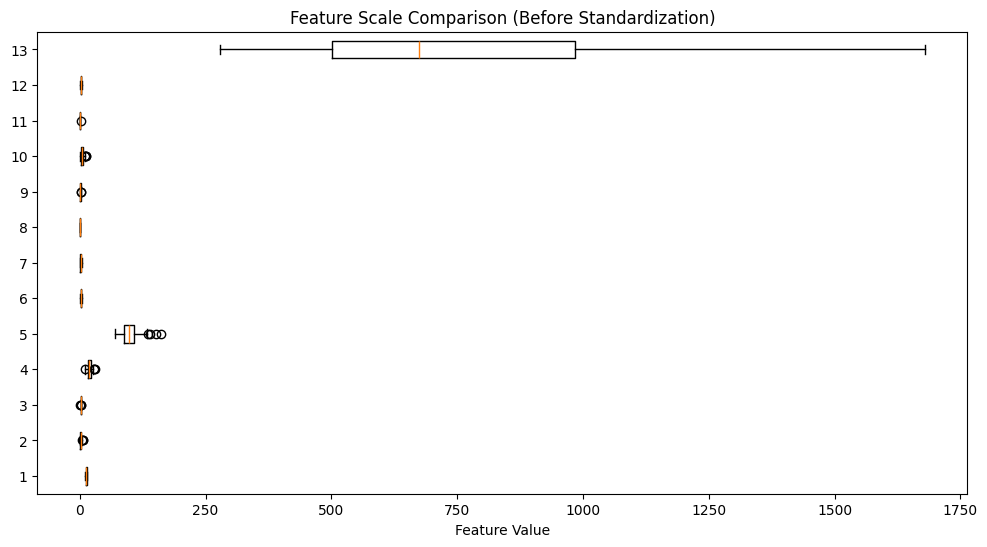

In [5]:
plt.figure(figsize=(12, 6))
plt.boxplot(X, vert=False)
plt.title("Feature Scale Comparison (Before Standardization)")
plt.xlabel("Feature Value")
plt.show()


## Preprocessing

We standardize the feature matrix before clustering.

Standardization rescales each feature to have zero mean and unit variance:

$$
X_{\text{std}} = \frac{X - \mu}{\sigma}
$$

This ensures that all features contribute equally to distance computations and improves clustering stability.


In [6]:
X_std = standardize(X)

## K-Means Objective Function

K-Means attempts to minimize the total **within-cluster sum of squared distances**:

$$
\sum_{i=1}^{n} \left\| x_i - \mu_{c(i)} \right\|^2
$$

where:
- $x_i$ is a data point
- $\mu_{c(i)}$ is the centroid of the cluster assigned to $x_i$
- $c(i)$ denotes the cluster index for point $i$


## K-Means Algorithm

The K-Means algorithm proceeds iteratively:

1. Initialize $K$ cluster centroids
2. Assign each data point to the nearest centroid
3. Update each centroid as the mean of its assigned points
4. Repeat until convergence or until the maximum number of iterations is reached


## Model Training

In [7]:
kmeans = KMeans(
    n_clusters=3,
    max_iter=300,
    tol=1e-4,
    random_state=42
)

kmeans.fit(X_std)


## Inertia

Inertia measures how tightly points are clustered around centroids.

It is defined as:

$$
\text{Inertia} = \sum_{i=1}^{n} \left\| x_i - \mu_{c(i)} \right\|^2
$$

Lower inertia indicates more compact clusters, but inertia always decreases as $K$ increases.


### Clustering Results

- Labels indicate cluster membership
- Centroids represent cluster means
- Inertia measures within-cluster variance

In [8]:
labels = kmeans.labels_
centers = kmeans.cluster_centers_

print("Cluster centers shape:", centers.shape)
print("Inertia:", kmeans.inertia_)


Cluster centers shape: (3, 13)
Inertia: 1277.9284888446423


## Elbow Method

The elbow method helps determine a reasonable number of clusters by plotting inertia as a function of $K$.

We look for a value of $K$ where the rate of decrease in inertia sharply slows, forming an "elbow" in the curve.

This point represents a good trade-off between model complexity and clustering quality.


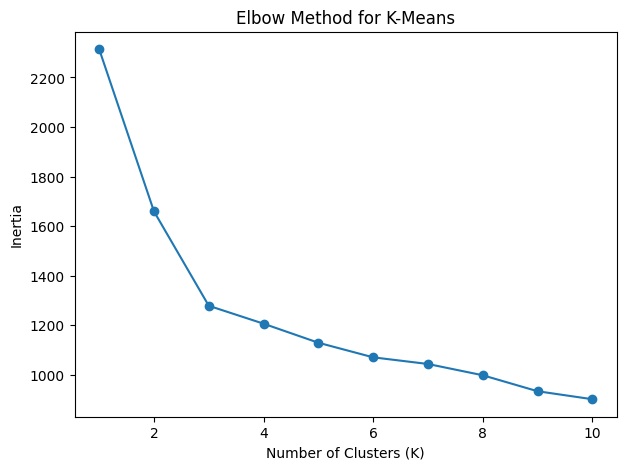

In [9]:
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_std)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


### Interpretation: 

The curve begins to flatten around 𝐾 = 3, suggesting diminishing returns beyond this point.

## PCA for Visualization

Because the dataset is high-dimensional, we use Principal Component Analysis (PCA) to project the data into two dimensions for visualization.

PCA finds orthogonal directions of maximum variance in the data.

Important note:
- PCA is used **only for visualization**
- Clustering is performed in the original standardized feature space


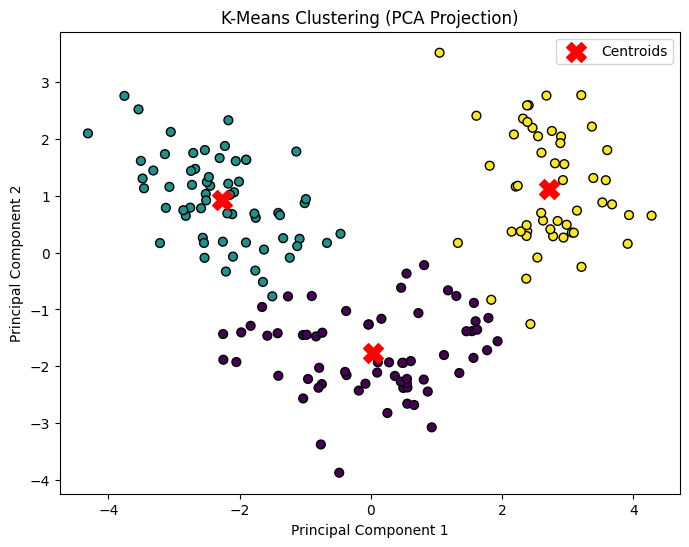

In [10]:
X_centered = X_std - X_std.mean(axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
X_pca = X_centered @ Vt[:2].T

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="viridis",
    s=40,
    edgecolor="k"
)

plt.scatter(
    centers @ Vt[:2].T[:, 0],
    centers @ Vt[:2].T[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (PCA Projection)")
plt.legend()
plt.show()


## Interpreting the Clusters

After fitting K-Means, each observation is assigned to the cluster with the
nearest centroid.

When reading the results, it is helpful to keep in mind:

- points in the same cluster are similar according to the distance measure
- cluster centers summarize the average location of each group
- separation in the PCA plot suggests that K-Means has identified distinct
  patterns in the data
- overlap between groups may indicate that the clusters are not strongly
  separated in the original feature space

Because this is an unsupervised method, the clusters do not automatically come
with real-world labels. They should be interpreted as data-driven groupings,
not as guaranteed categories.


## Limitations of K-Means

Although K-Means is widely used, it also has some important weaknesses:

- you must choose the number of clusters in advance
- results can depend on the starting centroids
- the method works best for roughly spherical and similarly sized groups
- it can be affected by outliers and unusual observations
- it may perform poorly when clusters overlap heavily or have irregular shapes

For these reasons, K-Means is often a strong starting point, but it should be
checked against visual evidence and domain knowledge.


## Conclusion

This notebook demonstrated how to apply K-Means clustering from scratch to a
real dataset.

The main ideas are:

- K-Means partitions observations into groups based on distance to cluster
  centers
- scaling the variables is an important preprocessing step
- the elbow method provides a practical way to compare choices of `K`
- PCA is helpful for displaying cluster structure in a lower-dimensional view

In short, K-Means is an accessible and effective clustering method for
exploratory analysis, especially as a first unsupervised learning baseline.
